# Singularity and Rank of Linear Transformations

*Course notes for **Math for Machine Learning**, C1 · W4 · L1 · V02 — "Singularity and Rank of Linear Transformations" (DeepLearning.AI).*

Since matrices correspond to linear transformations, the notions of **singular / non-singular** carry over to transformations — and there's a beautiful geometric way to see them. The same picture also reveals the **rank**. We cover:

- The **image** of a transformation and what **non-singular** means geometrically (covers the whole plane).
- Singular transformations that collapse the plane onto a **line** or even a **point**.
- **Rank = the dimension of the image**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. The image, and what non-singular means

The matrix $\begin{pmatrix} 3 & 1 \\ 1 & 2 \end{pmatrix}$ sends the blue square grid to an orange parallelogram grid — a **change of basis**. Crucially, that orange grid **covers every point of the plane**.

The set of points reached on the right is the **image** of the transformation. The defining trait:

> If the image covers the **entire plane**, the transformation is **non-singular**. If it covers only part of the plane, it is **singular**.

In [2]:
A = np.array([[3, 1],
              [1, 2]])
for p in [(0, 0), (1, 0), (0, 1), (1, 1)]:
    print(f'{p} -> {A @ np.array(p)}')
print('columns point in different directions -> image is the whole plane (non-singular)')

(0, 0) -> [0 0]
(1, 0) -> [3 1]
(0, 1) -> [1 2]
(1, 1) -> [4 3]
columns point in different directions -> image is the whole plane (non-singular)


## 2. A singular transformation collapses the plane to a line

Now take $\begin{pmatrix} 1 & 1 \\ 2 & 2 \end{pmatrix}$. Watch where the basis goes:

$$ (1,0)\mapsto(1,2), \quad (0,1)\mapsto(1,2), \quad (1,1)\mapsto(2,4). $$

Both basis vectors land on the **same line**, so the unit square maps to a **degenerate parallelogram** — just a line segment. No matter how the grid is drawn, its image can only cover **that one line**, never the full plane. That's exactly what **singular** looks like geometrically.

In [3]:
S = np.array([[1, 1],
              [2, 2]])
for p in [(0, 0), (1, 0), (0, 1), (1, 1)]:
    print(f'{p} -> {S @ np.array(p)}')
print('both columns are (multiples of) (1,2) -> image collapses onto the line y = 2x')

(0, 0) -> [0 0]
(1, 0) -> [1 2]
(0, 1) -> [1 2]
(1, 1) -> [2 4]
both columns are (multiples of) (1,2) -> image collapses onto the line y = 2x


## 3. An even more singular transformation collapses to a point

The **zero matrix** $\begin{pmatrix} 0 & 0 \\ 0 & 0 \end{pmatrix}$ sends **every** vector to the origin $(0,0)$. The image isn't a plane, isn't even a line — it's a single **point**. This is as singular as it gets.

In [4]:
Z = np.array([[0, 0],
              [0, 0]])
for p in [(1, 0), (0, 1), (5, -3), (1, 1)]:
    print(f'{p} -> {Z @ np.array(p)}')
print('everything lands on the origin -> image is a single point')

(1, 0) -> [0 0]
(0, 1) -> [0 0]
(5, -3) -> [0 0]
(1, 1) -> [0 0]
everything lands on the origin -> image is a single point


## 4. Seeing all three at once

Transform a whole grid of points by each matrix. The non-singular map fills the plane; the singular maps collapse it to a line, then to a point.

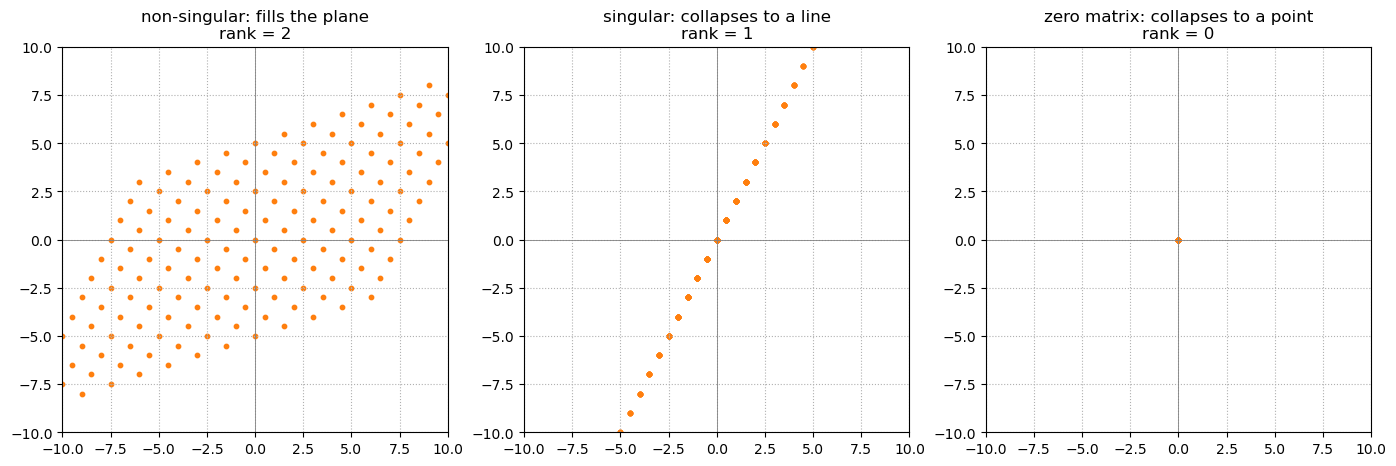

In [5]:
xs, ys = np.meshgrid(np.linspace(-3, 3, 13), np.linspace(-3, 3, 13))
grid = np.vstack([xs.ravel(), ys.ravel()])   # 2 x N

fig, axes = plt.subplots(1, 3, figsize=(14, 4.7))
for ax, Mx, ttl in [(axes[0], A, 'non-singular: fills the plane'),
                    (axes[1], S, 'singular: collapses to a line'),
                    (axes[2], Z, 'zero matrix: collapses to a point')]:
    out = Mx @ grid
    ax.scatter(out[0], out[1], s=10, color='C1')
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
    ax.set_aspect('equal'); ax.grid(True, ls=':')
    ax.set_title(f'{ttl}\nrank = {np.linalg.matrix_rank(Mx)}')
    ax.set_xlim(-10, 10); ax.set_ylim(-10, 10)
plt.tight_layout(); plt.show()

## 5. Rank = dimension of the image

The **dimension of the image** gives the **rank** of the matrix:

| matrix | image | dimension = **rank** |
|---|---|---|
| $\begin{pmatrix}3&1\\1&2\end{pmatrix}$ | plane | **2** (non-singular) |
| $\begin{pmatrix}1&1\\2&2\end{pmatrix}$ | line | **1** (singular) |
| $\begin{pmatrix}0&0\\0&0\end{pmatrix}$ | point | **0** |

So the geometric picture gives another way to compute rank: **rank = the dimension of the space the transformation maps onto**. A full-rank $n\times n$ matrix (rank $n$) is non-singular; any smaller rank is singular.

In [6]:
for name, Mx in [('A (plane)', A), ('S (line)', S), ('Z (point)', Z)]:
    r = np.linalg.matrix_rank(Mx)
    print(f'{name:12s} rank = {r}   ->  {"non-singular" if r == Mx.shape[0] else "singular"}')

A (plane)    rank = 2   ->  non-singular
S (line)     rank = 1   ->  singular
Z (point)    rank = 0   ->  singular


## Summary

- The **image** of a transformation is the set of points it can reach. **Non-singular** $\iff$ the image is the **whole plane**; **singular** $\iff$ it covers only a lower-dimensional piece.
- Singular transformations **collapse dimensions**: onto a **line**, or (for the zero matrix) onto a single **point**.
- **Rank = dimension of the image**: $2$ for the plane, $1$ for a line, $0$ for a point. A full-rank $n \times n$ matrix is non-singular; anything less is singular.
- In NumPy: `np.linalg.matrix_rank(M)`.